In [1]:
%loadlibs
import random

Loaded libraries:
	- numpy (np)
	- matplotlib.pyplot (plt)
	- torch
	- torch.nn (nn)
	- torch.optim (optim)
	- tqdm


In [12]:
def create_pde_loss(min_terms=1, max_terms=3, coeff_range=(-2.0, 2.0)):
    """
    Randomly generates a pde_loss(model, t) function:
      - LHS: 1st or 2nd order derivative of model output w.r.t. t
      - RHS: random linear combination of randomly chosen nonlinear terms

    The returned function has these attributes attached for inspection/logging:
      .order   -> 1 or 2
      .coeffs  -> list of sampled coefficients
      .n_terms -> number of terms in the RHS
      .equation_str -> human-readable string, e.g. "x''(t) = 1.300*x^2 - 0.700*sin(t)"
    """
    order = random.choice([1, 2])

    term_pool = [
        ("x",         lambda x_t, t: x_t),
        ("x^2",       lambda x_t, t: x_t**2),
        ("x^3",       lambda x_t, t: x_t**3),
        ("sin(x)",    lambda x_t, t: torch.sin(x_t)),
        ("cos(x)",    lambda x_t, t: torch.cos(x_t)),
        ("sin(t)",    lambda x_t, t: torch.sin(t)),
        ("cos(t)",    lambda x_t, t: torch.cos(t)),
        ("t*x",       lambda x_t, t: t * x_t),
        ("t",         lambda x_t, t: t),
        ("exp(-x^2)", lambda x_t, t: torch.exp(-x_t**2)),
        ("x*(1-x)",   lambda x_t, t: x_t * (1 - x_t)),
    ]

    n_terms = random.randint(min_terms, max_terms)
    chosen = random.sample(term_pool, n_terms)
    labels = [lbl for lbl, _ in chosen]
    term_fns = [fn for _, fn in chosen]
    coeffs = [random.uniform(*coeff_range) for _ in range(n_terms)]

    def rhs_fn(x_t, t):
        total = 0.0
        for c, term in zip(coeffs, term_fns):
            total = total + c * term(x_t, t)
        return total

    def build_equation_str():
        lhs_str = "x'(t)" if order == 1 else "x''(t)"
        parts = []
        for i, (c, lbl) in enumerate(zip(coeffs, labels)):
            sign = "-" if c < 0 else ("" if i == 0 else "+")
            sep = " " if i == 0 else " "
            parts.append(f"{sign}{sep}{abs(c):.3f}*{lbl}")
        rhs_str = " ".join(parts)
        return f"{lhs_str} = {rhs_str}"

    def pde_loss(model, t, x0):
        x_t = model(t, x0)

        dx_dt = torch.autograd.grad(
            x_t, t, grad_outputs=torch.ones_like(x_t),
            create_graph=True
        )[0]

        if order == 1:
            lhs = dx_dt
        else:
            d2x_dt2 = torch.autograd.grad(
                dx_dt, t, grad_outputs=torch.ones_like(dx_dt),
                create_graph=True
            )[0]
            lhs = d2x_dt2

        rhs = rhs_fn(x_t, t)
        return ((lhs - rhs) ** 2).mean()

    pde_loss.order = order
    pde_loss.coeffs = coeffs
    pde_loss.n_terms = n_terms
    pde_loss.term_labels = labels
    pde_loss.rhs_fn = rhs_fn
    pde_loss.equation_str = build_equation_str()

    return pde_loss

In [13]:
import math
import numpy as np
 
 
def _as_system(pde_loss):
    """
    Wrap pde_loss.rhs_fn into a uniform first-order state-derivative
    function f(state, t) -> dstate/dt, regardless of whether the
    original equation was 1st or 2nd order.
 
    State vector convention:
        order 1: state = [x]
        order 2: state = [x, v]   where v = x'
    """
    order = pde_loss.order
    rhs_fn = pde_loss.rhs_fn  # rhs_fn(x, t) -> same shape as x
 
    if order == 1:
        def f(state, t):
            x = state[0]
            return torch.tensor(np.array([rhs_fn(x, t)]))
    elif order == 2:
        def f(state, t):
            x, v = state[0], state[1]
            return torch.tensor(np.array([v, rhs_fn(x, t)]))
    else:
        raise ValueError(f"Unsupported order: {order} (expected 1 or 2)")
 
    return f, order
 
 
def solve_ode(pde_loss, x0, t0=0.0, t_end=10.0, dt=0.01, v0=None, method="rk4"):
    """
    Integrate the equation described by `pde_loss` forward in time using
    finite differences.
 
    Parameters
    ----------
    pde_loss : function returned by create_pde_loss()
        Must have .order (1 or 2) and .rhs_fn (callable(x, t)) attributes.
    x0 : float
        Initial condition x(t0).
    t0, t_end : float
        Integration interval.
    dt : float
        Step size (uniform grid).
    v0 : float, optional
        Initial derivative x'(t0). REQUIRED if pde_loss.order == 2.
        Ignored (and not needed) if order == 1.
    method : {"rk4", "euler"}
        Finite-difference time-stepping scheme.
 
    Returns
    -------
    t : (N+1,) ndarray  -- time grid
    x : (N+1,) ndarray  -- solution x(t)
    v : (N+1,) ndarray or None  -- derivative x'(t), only for order-2 equations
    """
    order = pde_loss.order
 
    if order == 2 and v0 is None:
        raise ValueError(
            "This equation is 2nd order (involves x''(t)); you must supply "
            "v0 = x'(t0) as the second initial condition."
        )
    if order == 1 and v0 is not None:
        v0 = None
 
    f, order = _as_system(pde_loss)
 
    n_steps = int(round((t_end - t0) / dt))
    t = torch.linspace(t0, t0 + n_steps * dt, n_steps + 1)
 
    state_dim = 1 if order == 1 else 2
    state = torch.zeros((n_steps + 1, state_dim))
    state[0, 0] = x0
    if order == 2:
        state[0, 1] = v0
 
    if method == "euler":
        step = _euler_step
    elif method == "rk4":
        step = _rk4_step
    else:
        raise ValueError(f"Unknown method: {method!r} (use 'euler' or 'rk4')")
 
    for i in range(n_steps):
        state[i + 1] = step(f, state[i], t[i], dt)
 
    x = state[:, 0]
    v = state[:, 1] if order == 2 else None
    return t, x, v
 
 
def _euler_step(f, s, t, dt):
    """One explicit-Euler finite-difference step: s_{i+1} = s_i + dt*f(s_i, t_i)."""
    return s + dt * f(s, t)
 
 
def _rk4_step(f, s, t, dt):
    """One classical 4th-order Runge-Kutta finite-difference step."""
    k1 = f(s, t)
    k2 = f(s + 0.5 * dt * k1, t + 0.5 * dt)
    k3 = f(s + 0.5 * dt * k2, t + 0.5 * dt)
    k4 = f(s + dt * k3, t + dt)
    return s + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

In [14]:
pde_loss = create_pde_loss()
print(pde_loss.equation_str)

x''(t) =  1.090*x*(1-x) - 1.703*t


  0%|          | 0/10000 [00:00<?, ?it/s]

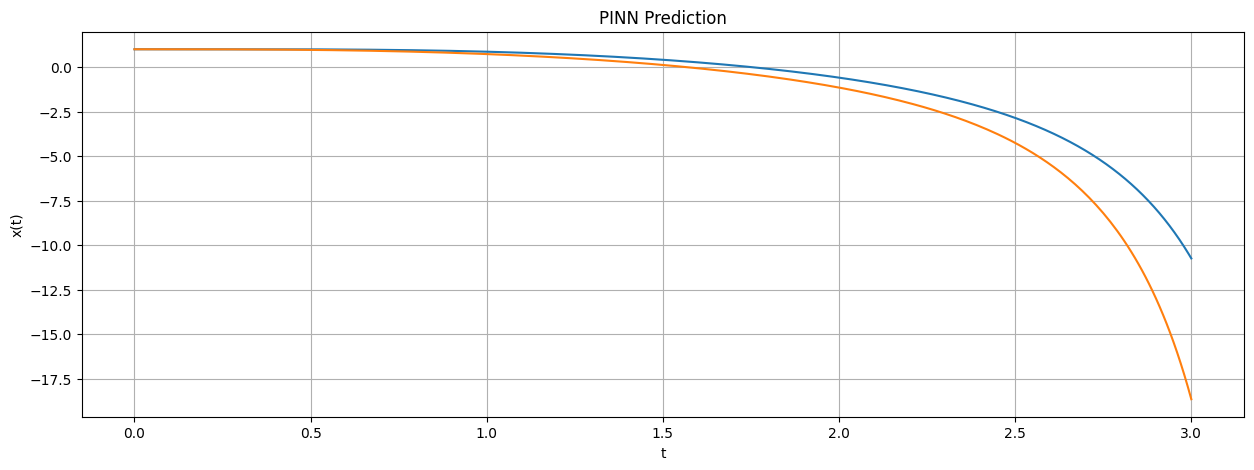

In [15]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_size = 20
        self.l1 = nn.Linear(1, self.layer_size)
        self.l2 = nn.Linear(self.layer_size, self.layer_size)
        self.l3 = nn.Linear(self.layer_size, self.layer_size)
        self.l4 = nn.Linear(self.layer_size, 1)
        self.activation = nn.Tanh()

    def forward(self, t, x0):
        x = self.activation(self.l1(t))
        x = self.activation(self.l2(x))
        x = self.activation(self.l3(x))
        x = self.l4(x)
        return t**2 * x + x0

n_epochs = 10000
n_points = 1024
t_max = 3
x0 = 1

model = Model()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

for i in (pbar:=tqdm(range(n_epochs))):
    optimizer.zero_grad()
    t = ((torch.rand(n_points, requires_grad=True).unsqueeze(1))-0.5)*t_max*2
    loss = pde_loss(model, t, x0)
    loss.backward()
    if i%100 == 99:
        pbar.set_description(f"Loss: {loss.item():.3e}")
    optimizer.step()

plt.figure(figsize=(15, 5))
t = torch.linspace(0, t_max, 10000)
plt.plot(t, model(t.unsqueeze(-1), x0).squeeze().detach())
t_fd, x_fd, _ = solve_ode(pde_loss, x0=x0, v0=0, t0=0, t_end=t_max)
plt.plot(t_fd, x_fd)
#plt.ylim([-1, 10])
plt.ylabel("x(t)")
plt.xlabel("t")
plt.title("PINN Prediction")
plt.grid()

plt.show()